In [1]:
import pandas as pd
#load the dataset
file_path = 'advertising.csv'
df = pd.read_csv(file_path)
df

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,27-03-2016 00:53,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,04-04-2016 01:39,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,13-03-2016 20:35,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,10-01-2016 02:31,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,03-06-2016 03:36,0
...,...,...,...,...,...,...,...,...,...,...
995,62.24,55,26386.56,249.15,Optimized content strategy,South Manuel,0,Canada,05-09-2016 18:00,0
996,49.46,31,54899.83,261.55,Optimized content strategy,Davidton,1,Italy,06-09-2016 00:00,1
997,52.12,48,25621.46,136.30,Organic bottom-line service-desk,Davidton,0,Canada,06-09-2016 06:00,0
998,68.85,19,38609.61,277.05,Optimized content strategy,West Terrifurt,0,San Marino,06-09-2016 12:00,0


In [2]:
# display basic info and the first few rows
basic_info = df.info()
head = df.head()

df.describe(),head

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


(       Daily Time Spent on Site          Age   Area Income  \
 count               1000.000000  1000.000000   1000.000000   
 mean                  60.127090    39.378000  49547.455500   
 std                   17.530044    12.553275  17358.107043   
 min                   30.130000    18.000000  20005.540000   
 25%                   44.970000    28.000000  34492.435000   
 50%                   60.160000    39.000000  49780.500000   
 75%                   75.485000    51.000000  64500.697500   
 max                   89.970000    60.000000  79954.510000   
 
        Daily Internet Usage         Male  Clicked on Ad  
 count            1000.00000  1000.000000    1000.000000  
 mean              202.24741     0.513000       0.485000  
 std                57.99407     0.500081       0.500025  
 min               100.14000     0.000000       0.000000  
 25%               152.99500     0.000000       0.000000  
 50%               203.81000     1.000000       0.000000  
 75%              

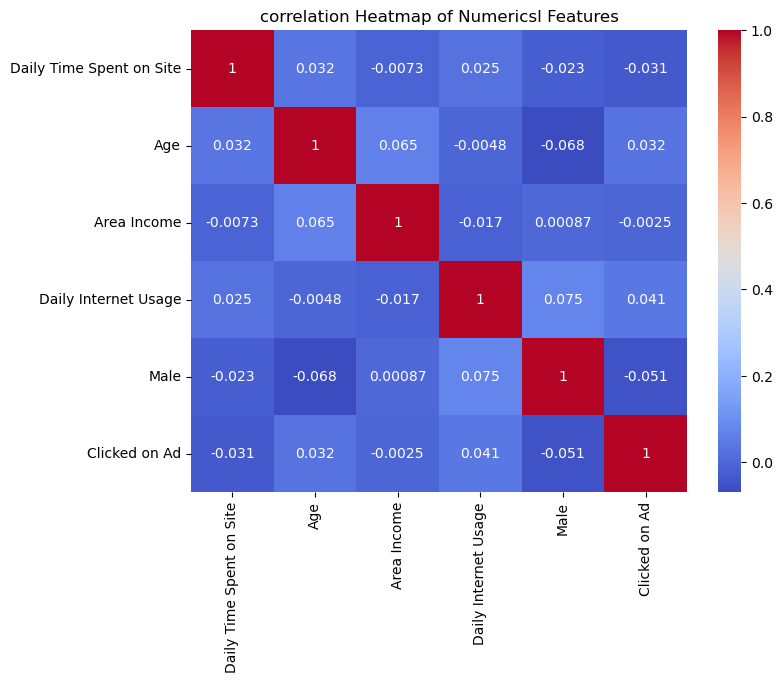

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

#correlation heatmap of numerical feautures
plt.figure (figsize=(8,6))
sns.heatmap(df.corr(numeric_only = True),annot = True,   cmap = 'coolwarm')

plt.title('correlation Heatmap of Numericsl Features')
plt.show()

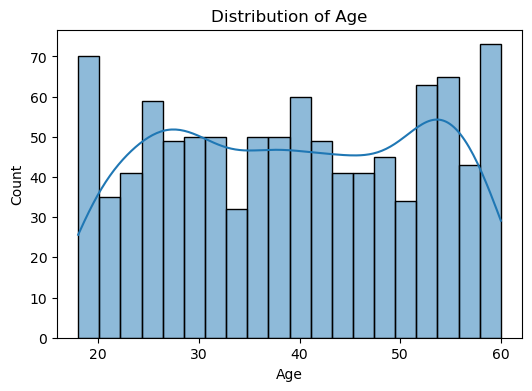

In [4]:
#Distibution of age
plt.figure(figsize =(6,4))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.show()

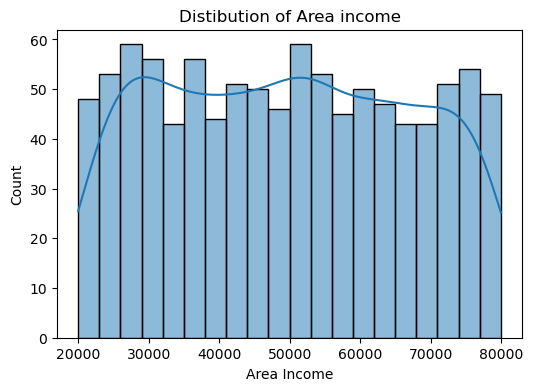

In [5]:
#Distibution of Area income
plt.figure(figsize =(6, 4))
sns.histplot(df['Area Income'], bins=20, kde=True)
plt.title('Distibution of Area income')
plt.xlabel('Area Income')
plt.show()

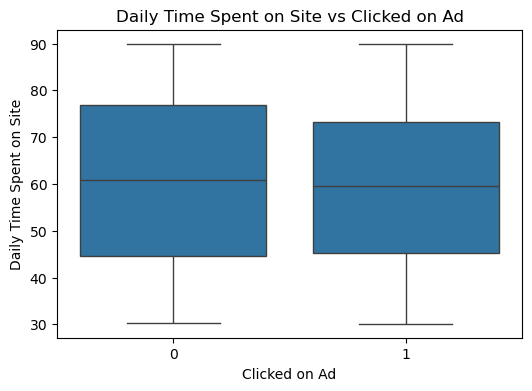

In [6]:
# boxplot Daily Time Spent on Site vs Clicked on Ad
plt.figure(figsize=(6, 4))
sns.boxplot(x='Clicked on Ad', y='Daily Time Spent on Site', data=df)
plt.title('Daily Time Spent on Site vs Clicked on Ad')
plt.show()

In [7]:
# Convert 'Timestamp' to datetime and extract new features
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%d-%m-%Y %H:%M')
df['Hour'] = df ['Timestamp'].dt.hour
df['Day'] = df['Timestamp'].dt.dayofweek

#Check the new columns
df[['Timestamp', 'Hour', 'Day']].head()

,Timestamp,Hour,Day
0,2016-03-27 00:53:00,0,6
1,2016-04-04 01:39:00,1,0
2,2016-03-13 20:35:00,20,6
3,2016-01-10 02:31:00,2,6
4,2016-06-03 03:36:00,3,4


In [8]:
#Define feature set and target
X = df[['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage']]
y = df['Clicked on Ad']

In [9]:
from sklearn.linear_model import LogisticRegression
#Initialize and fit Logistic Reegression model
logmodel = LogisticRegression()
logmodel.fit(X, y)

#predictions
y_pred = logmodel.predict(X)
print(y_pred)

[0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 1 1 0 0 0 0 1 1 0 0 1 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 1 1 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 1
 0 1 0 0 0 0 1 0 1 1 0 1 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0
 1 0 1 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 0 0 0 0 1 0 0 0 0 1 0 0 1 1 0 1 1
 0 0 0 1 0 1 0 0 1 1 0 0 0 0 0 1 0 0 1 0 1 1 0 0 0 1 0 1 1 1 0 0 0 0 0 1 0
 1 0 0 0 0 1 0 0 1 0 0 0 0 0 1 1 1 1 0 1 1 0 0 0 1 0 0 0 1 1 1 1 0 0 0 0 1
 0 1 1 0 1 1 0 0 0 0 0 0 0 1 0 1 1 0 1 1 0 0 1 1 1 0 0 0 1 0 0 1 0 0 0 0 0
 0 1 0 0 0 1 0 0 0 1 1 0 0 0 0 1 0 0 0 0 1 1 1 1 0 0 1 0 0 0 1 0 0 0 0 1 0
 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 1 1 1 0 1 0 0 0 0 1 1 1 0 1 0 0 0 1 1 0 0 0
 0 0 1 1 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 1 0 0 0 1 0
 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 1 0 1 1 0 0 0 0 0 0 1
 0 1 1 0 0 1 0 1 0 0 0 1 1 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 1 0 1 0 0 0 0 0 0
 0 1 0 0 1 1 0 0 1 0 1 1 

In [10]:
#Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

conf_matrix = confusion_matrix(y_pred , y_pred)
accuracy = accuracy_score(y_pred, y_pred) 
print(conf_matrix)

[[689   0]
 [  0 311]]


In [11]:
print("Accuracy score:", accuracy)

Accuracy score: 1.0


In [12]:
class_report = classification_report(y,  y_pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.54      0.72      0.62       515
           1       0.54      0.35      0.42       485

    accuracy                           0.54      1000
   macro avg       0.54      0.53      0.52      1000
weighted avg       0.54      0.54      0.52      1000



In [13]:
# prompt: generate the accuracy score, recall, precision, f1score, specificity
import numpy as np
from sklearn.metrics import recall_score, precision_score, f1_score

#Assuming 'y' and 'predictions' are alredy defined from the previous code

#calculate recall
recall = recall_score(y, y_pred)
print("Recall:", np.round(recall,2))

#calculate precision
precision = precision_score(y,  y_pred)
print("precision:", np.round(precision,2))

#calculate F1-score
f1 = f1_score(y,  y_pred)
print("F1-score:", np.round(f1,2))

#calculate specificity
tn, fp, fn, tp = confusion_matrix(y,  y_pred).ravel()
specificity = tn / (tn + fp)
print("Specificity:", np.round(specificity,2))

Recall: 0.35
precision: 0.54
F1-score: 0.42
Specificity: 0.72


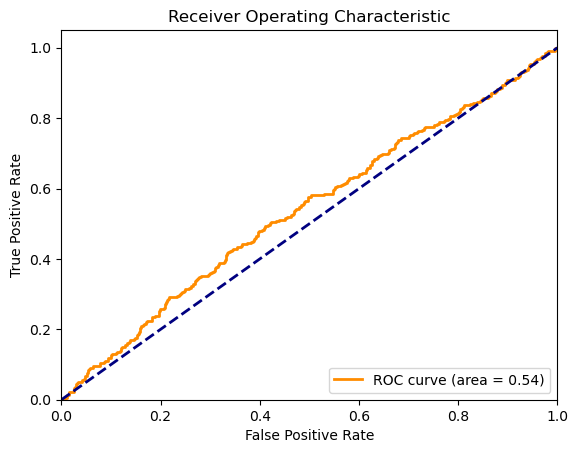

AUC score: 0.5388970073065759


In [14]:
from sklearn.metrics  import roc_curve, auc

# predictions on the set
predictions = logmodel.predict(X)
y_pred_proba = logmodel.predict_proba(X)[:,1]

# Roc Curve and Auc
fpr, tpr, thresholds = roc_curve(y, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

print(f"AUC score: {roc_auc}")